In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
# Lucky number
random_state = 8

In [63]:
# Loading dataset
dataset = pd.read_csv('../../data/3-processed/phase4.csv')
dataset.head()

,sampleid,answerdate,sex,age,ageid,prefecture,area,married,child,hincome,...,mental_group,covid_group,k6_group3,k6_group2,phq9_%,gad_%,phq9_item9,phq9_si,lsns_group,audit_group
0,3793,2024-05-13,1.0,57.0,10.0,40.0,8.0,2.0,2.0,4.0,...,4.0,4.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0
1,9703,2024-05-14,2.0,70.0,11.0,28.0,5.0,2.0,2.0,7.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,11532,2024-05-11,1.0,52.0,9.0,13.0,3.0,1.0,1.0,3.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,15778,2024-05-10,1.0,66.0,11.0,27.0,5.0,2.0,2.0,4.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,18713,2024-05-10,1.0,63.0,11.0,13.0,3.0,2.0,2.0,7.0,...,4.0,4.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [64]:
dataset.columns.tolist()

['sampleid',
 'answerdate',
 'sex',
 'age',
 'ageid',
 'prefecture',
 'area',
 'married',
 'child',
 'hincome',
 'pincome',
 'job',
 'student',
 'number_fam',
 'schoolgrade',
 'yearsenrolled',
 'vacnum',
 'med_self',
 'medself_covid',
 'med_fam',
 'medfam_covid',
 'current_physical',
 'past_physical',
 'current_mental',
 'past_mental',
 'current_covid19',
 'past_covid19',
 'exercise',
 'healthydiet',
 'favoriteactivity',
 'interaction_offline',
 'interaction_online',
 'pb_continuous',
 'pb_altruistic',
 'pb_avoidant',
 'trust_gov',
 'trust_sm',
 'vaccination_will',
 'pb_understanding',
 'optimism',
 'healthysleep',
 'deteriorationeconomy',
 'deteriorationinteract',
 'frustration',
 'covidanxiety',
 'covidsleepless',
 'difficultyliving',
 'difficultywork',
 'ptg1_s22',
 'ptg2_s23',
 'ptg3_s24',
 'ptg4_s25',
 'ptg5_s_26',
 'ptg6_s27',
 'social_capital_q8s1',
 'social_capital_q8s2',
 'social_capital_q8s3',
 'social_capital_q8s4',
 'social_capital_q8s5',
 'social_capital_q9s1',
 'social_ca

In [65]:
# Setting attributes
dataset = dataset[[
        'sex',                      # 1 - Male; 2 - Female
        'age',
        #'age_group',                # Age    
        'married',                  # 1 - Unmarried; 2 - Married
        'child',                    # 1 - No children; 2 - With children
        'hincome',
        #'hincome_group',            # 1 to 5, increasing annual household income
        'pincome',                  # Same categorization as HINCOME
        'number_fam',               # Number of cohabitants
        
        'job_group',                # 1 - Employed; 2 - Homemaker; 3 - Student; 4 - Unemployed; 5 - Others

        # 1 - Yes; 2 - No
        'med_self',                 # I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.)
        'medself_covid',            # As a medical worker, I am dealing with new corona patients.
        'med_fam',                  # Have a family member who is a healthcare worker
        'medfam_covid',             # There is a person in the family who is dealing with new corona patients as a medical worker.
        'current_physical',         # Whether the respondent has been treated for a physical illness in the past
        'past_physical',            # Whether the respondent is currently being treated for a mental disorder
        'current_mental',           # Whether the respondent has been treated for mental illness in the past
        'past_mental',              # Currently being treated for COVID-19
        'current_covid19',          # Currently undergoing treatment for COVID-19.
        'past_covid19',             # Have received treatment for COVID-19 in the past.
        
        # 1: Not at all true - 7: Very true
        'exercise',                 # I try to exercise to stay healthy (both indoors and outdoors). 
        'healthydiet',              # I ate meals with nutritional balance in mind.
        'healthysleep',             # My wake up and bedtimes were pretty consistent.
        'favoriteactivity',         # I engaged in hobbies and other activities that I could become passionate about.
        'interaction_offline',      # I interacted with family and friends in person (excluding work and classes).
        'interaction_online',       # Interacted with family and friends online via chat or video calls (excluding work or class).
        
        'pb_continuous',            # We continued to take preventive actions against the new coronavirus infection (wearing a mask, washing hands, limiting going out, etc.).
        'pb_altruistic',            # Voluntarily took preventive actions (wearing a mask, washing hands, limiting going out, etc.) to prevent the spread of the new coronavirus to family members and others.
        'pb_avoidant',              # To avoid social criticism and pressure, they took preventive actions (wearing masks, washing hands, limiting going out, etc.).
        'pb_understanding',         # They understood the necessity and importance of taking preventive actions.     
        'optimism',                 # I thought positively about the future.
        'deteriorationeconomy',     # The economic situation worsened.
        'deteriorationinteract',    # Relationships with close people such as family and friends have deteriorated.
        'frustration',              # Changes in my life sometimes made me irritable and angry.
        'covidanxiety',             # Watching the news about the new coronavirus made me feel nervous and anxious.
        'covidsleepless',           # I couldn't sleep because I was worried about catching the new coronavirus.
        'difficultyliving',         # Daily life was disrupted, with shortages of COVID-19 prevention supplies (masks, thermometers, etc.) and other daily necessities.
        'difficultywork',           # Changes in my lifestyle have caused problems with my work and studies.
 
        'k6_total',                 # Psychological stress
        #'k6_group2',
        'phq9_total',               # Depression
        #'phq9_%',
        'lsns6_total',              # Social Network
        #'lsns_group',
        'sss8_total',               # Somatic symptoms
        #'shai',                    # Health anxiety
        'gad7_total',               # Anxiety
        #'gad_%',                    
        'shs_total',                # Subjective well-being
        
        'ucla_total'                # Loneliness
    ]]
dataset

,sex,age,married,child,hincome,pincome,number_fam,job_group,med_self,medself_covid,...,covidsleepless,difficultyliving,difficultywork,k6_total,phq9_total,lsns6_total,sss8_total,gad7_total,shs_total,ucla_total
0,1.0,57.0,2.0,2.0,4.0,3.0,2.0,1.0,2.0,2.0,...,5.0,5.0,5.0,12.0,15.0,4.0,18.0,14.0,4.00,24.0
1,2.0,70.0,2.0,2.0,7.0,1.0,3.0,2.0,2.0,2.0,...,1.0,1.0,6.0,1.0,0.0,18.0,1.0,0.0,4.50,11.0
2,1.0,52.0,1.0,1.0,3.0,3.0,1.0,1.0,2.0,2.0,...,1.0,1.0,1.0,1.0,2.0,0.0,1.0,0.0,4.00,32.0
3,1.0,66.0,2.0,2.0,4.0,2.0,3.0,1.0,2.0,2.0,...,1.0,1.0,1.0,0.0,0.0,13.0,0.0,0.0,5.50,21.0
4,1.0,63.0,2.0,2.0,7.0,7.0,1.0,1.0,2.0,2.0,...,2.0,4.0,4.0,0.0,2.0,18.0,0.0,0.0,5.25,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2654,1.0,57.0,2.0,2.0,2.0,2.0,3.0,1.0,2.0,2.0,...,4.0,5.0,5.0,12.0,4.0,6.0,13.0,7.0,4.00,25.0
2655,1.0,55.0,2.0,2.0,7.0,7.0,3.0,1.0,2.0,2.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.00,25.0
2656,2.0,50.0,2.0,1.0,5.0,1.0,1.0,2.0,2.0,2.0,...,3.0,3.0,3.0,13.0,6.0,4.0,5.0,0.0,3.75,26.0
2657,2.0,33.0,1.0,1.0,4.0,4.0,0.0,1.0,2.0,2.0,...,1.0,2.0,1.0,2.0,3.0,3.0,14.0,2.0,4.00,27.0


# Preprocessing

In [66]:
dataset_cleaned = dataset.copy()

In [67]:
dataset_cleaned.columns[dataset_cleaned.isna().any()].tolist()

[]

In [68]:
mode_value = dataset_cleaned.loc[~dataset_cleaned['hincome'].isin([10]) & dataset_cleaned['hincome'].notna(), 'hincome'].mode()[0]
dataset_cleaned['hincome'] = dataset_cleaned['hincome'].replace([10, np.nan], mode_value)

In [69]:
mode_value = dataset_cleaned.loc[~dataset_cleaned['pincome'].isin([10]) & dataset_cleaned['pincome'].notna(), 'pincome'].mode()[0]
dataset_cleaned['pincome'] = dataset_cleaned['pincome'].replace([10, np.nan], mode_value)

In [70]:
dataset_cleaned.columns[dataset_cleaned.isna().any()].tolist()

[]

In [71]:
# Sex: 1 - Male; 2 - Female
column = 'sex'
def categories(x):
    if x == 1:
        return 'Male'
    elif x == 2:
        return 'Female'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# Married: 1 - Unmarried; 2 - Married
column = 'married'
def categories(x):
    if x == 1:
        return 'Unmarried'
    elif x == 2:
        return 'Married'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# Child: 1 - No children; 2 - With children
column = 'child'
def categories(x):
    if x == 1:
        return 'No children'
    elif x == 2:
        return 'With children'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# # Annual household income (JPY)
# # HINCOME group: 1 - < 2 million; 2 - 2-3.9 million; 3 - 4.0-5.9 million; 4 - 5.0-7.9 million; 5 - >= 8.0 million; 6 - Unknown
# column = 'hincome_group'
# def categories(x):
#     if x == 6: 
#         return None
#     else:
#         return x
# dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# # Household Income Group
# column = 'hincome'
# def categories(x):
#     if x == 1:
#         return 'Less than 2 million'
#     elif x == 2:
#         return '2 million to less than 4 million'
#     elif x == 3:
#         return '4 million to less than 6 million'
#     elif x == 4:
#         return '6 million to less than 8 million'
#     elif x == 5:
#         return '8 million to less than 10 million'
#     elif x == 6:
#         return '10 million to less than 12 million'
#     elif x == 7:
#         return '12 million to less than 15 million'
#     elif x == 8:
#         return '15 million to less than 20 million'
#     elif x == 9:
#         return '20 million yen or more'
#     else:
#         return None
# dataset_cleaned[column] = dataset_cleaned[column].apply(categories)
# 
# # Personal Annual Income
# column = 'pincome'
# def categories(x):
#     if x == 1:
#         return 'Less than 2 million'
#     elif x == 2:
#         return '2 million to less than 4 million'
#     elif x == 3:
#         return '4 million to less than 6 million'
#     elif x == 4:
#         return '6 million to less than 8 million'
#     elif x == 5:
#         return '8 million to less than 10 million'
#     elif x == 6:
#         return '10 million to less than 12 million'
#     elif x == 7:
#         return '12 million to less than 15 million'
#     elif x == 8:
#         return '15 million to less than 20 million'
#     elif x == 9:
#         return '20 million yen or more'
#     else:
#         return None
# dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

# Job Group
column = 'job_group'
def categories(x):
    if x == 1:
        return 'Employed'
    elif x == 2:
        return 'Homemaker'
    elif x == 3:
        return 'Student'
    elif x == 4: 
        return 'Unemployed'
    elif x == 5:
        return 'Others'
    else:
        return None
dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

In [72]:
dataset_cleaned 

,sex,age,married,child,hincome,pincome,number_fam,job_group,med_self,medself_covid,...,covidsleepless,difficultyliving,difficultywork,k6_total,phq9_total,lsns6_total,sss8_total,gad7_total,shs_total,ucla_total
0,Male,57.0,Married,With children,4.0,3.0,2.0,Employed,2.0,2.0,...,5.0,5.0,5.0,12.0,15.0,4.0,18.0,14.0,4.00,24.0
1,Female,70.0,Married,With children,7.0,1.0,3.0,Homemaker,2.0,2.0,...,1.0,1.0,6.0,1.0,0.0,18.0,1.0,0.0,4.50,11.0
2,Male,52.0,Unmarried,No children,3.0,3.0,1.0,Employed,2.0,2.0,...,1.0,1.0,1.0,1.0,2.0,0.0,1.0,0.0,4.00,32.0
3,Male,66.0,Married,With children,4.0,2.0,3.0,Employed,2.0,2.0,...,1.0,1.0,1.0,0.0,0.0,13.0,0.0,0.0,5.50,21.0
4,Male,63.0,Married,With children,7.0,7.0,1.0,Employed,2.0,2.0,...,2.0,4.0,4.0,0.0,2.0,18.0,0.0,0.0,5.25,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2654,Male,57.0,Married,With children,2.0,2.0,3.0,Employed,2.0,2.0,...,4.0,5.0,5.0,12.0,4.0,6.0,13.0,7.0,4.00,25.0
2655,Male,55.0,Married,With children,7.0,7.0,3.0,Employed,2.0,2.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.00,25.0
2656,Female,50.0,Married,No children,5.0,1.0,1.0,Homemaker,2.0,2.0,...,3.0,3.0,3.0,13.0,6.0,4.0,5.0,0.0,3.75,26.0
2657,Female,33.0,Unmarried,No children,4.0,4.0,0.0,Employed,2.0,2.0,...,1.0,2.0,1.0,2.0,3.0,3.0,14.0,2.0,4.00,27.0


In [73]:
columns = [
        'med_self',                 # I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.)
        'medself_covid',            # As a medical worker, I am dealing with new corona patients.
        'med_fam',                  # Have a family member who is a healthcare worker
        'medfam_covid',             # There is a person in the family who is dealing with new corona patients as a medical worker.
        'current_physical',         # Whether the respondent has been treated for a physical illness in the past
        'past_physical',            # Whether the respondent is currently being treated for a mental disorder
        'current_mental',           # Whether the respondent has been treated for mental illness in the past
        'past_mental',              # Currently being treated for COVID-19
        'current_covid19',          # Currently undergoing treatment for COVID-19.
        'past_covid19'              # Have received treatment for COVID-19 in the past.
]
 
def categories(x):
    if x == 1:
        return 'Yes'
    else:
        return 'No'
    
# Transform columns in categorical descriptions
for column in columns:
    dataset_cleaned[column] = dataset_cleaned[column].apply(categories)

In [74]:
dataset_cleaned

,sex,age,married,child,hincome,pincome,number_fam,job_group,med_self,medself_covid,...,covidsleepless,difficultyliving,difficultywork,k6_total,phq9_total,lsns6_total,sss8_total,gad7_total,shs_total,ucla_total
0,Male,57.0,Married,With children,4.0,3.0,2.0,Employed,No,No,...,5.0,5.0,5.0,12.0,15.0,4.0,18.0,14.0,4.00,24.0
1,Female,70.0,Married,With children,7.0,1.0,3.0,Homemaker,No,No,...,1.0,1.0,6.0,1.0,0.0,18.0,1.0,0.0,4.50,11.0
2,Male,52.0,Unmarried,No children,3.0,3.0,1.0,Employed,No,No,...,1.0,1.0,1.0,1.0,2.0,0.0,1.0,0.0,4.00,32.0
3,Male,66.0,Married,With children,4.0,2.0,3.0,Employed,No,No,...,1.0,1.0,1.0,0.0,0.0,13.0,0.0,0.0,5.50,21.0
4,Male,63.0,Married,With children,7.0,7.0,1.0,Employed,No,No,...,2.0,4.0,4.0,0.0,2.0,18.0,0.0,0.0,5.25,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2654,Male,57.0,Married,With children,2.0,2.0,3.0,Employed,No,No,...,4.0,5.0,5.0,12.0,4.0,6.0,13.0,7.0,4.00,25.0
2655,Male,55.0,Married,With children,7.0,7.0,3.0,Employed,No,No,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.00,25.0
2656,Female,50.0,Married,No children,5.0,1.0,1.0,Homemaker,No,No,...,3.0,3.0,3.0,13.0,6.0,4.0,5.0,0.0,3.75,26.0
2657,Female,33.0,Unmarried,No children,4.0,4.0,0.0,Employed,No,No,...,1.0,2.0,1.0,2.0,3.0,3.0,14.0,2.0,4.00,27.0


In [75]:
categorical_features = [
    'sex',
    'married',
    'child',
    'job_group',
    'med_self',                 # I am a healthcare professional (doctor, nurse, other healthcare professional, pharmacist, caregiver, etc.)
    'medself_covid',            # As a medical worker, I am dealing with new corona patients.
    'med_fam',                  # Have a family member who is a healthcare worker
    'medfam_covid',             # There is a person in the family who is dealing with new corona patients as a medical worker.
    'current_physical',         # Whether the respondent has been treated for a physical illness in the past
    'past_physical',            # Whether the respondent is currently being treated for a mental disorder
    'current_mental',           # Whether the respondent has been treated for mental illness in the past
    'past_mental',              # Currently being treated for COVID-19
    'current_covid19',          # Currently undergoing treatment for COVID-19.
    'past_covid19',             # Have received treatment for COVID-19 in the past.
]

In [76]:
initial_rows = len(dataset)

# Drop rows with NaN values (originally non-numeric values)
dataset_cleaned = dataset_cleaned.dropna()

row_count = len(dataset_cleaned)

print(f"Total number of rows: {row_count}")
print(f"Number of rows dropped: {initial_rows - row_count}")

Total number of rows: 2659
Number of rows dropped: 0


In [77]:
initial_rows = len(dataset_cleaned)

# Drop outliers in hincome and pincome
# https://medium.com/artificial-intelligence-101/handling-outliers-in-data-a-step-by-step-guide-using-python-be8471a021a9
Q1 = dataset_cleaned[['hincome', 'pincome']].quantile(0.25)
Q3 = dataset_cleaned[['hincome', 'pincome']].quantile(0.75)
IQR = Q3 - Q1

# Calculate lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering out outliers
dataset_cleaned = dataset_cleaned[~((dataset_cleaned[['hincome', 'pincome']] < lower_bound | 
                                    (dataset_cleaned[['hincome', 'pincome']] > upper_bound))).any(axis=1)]

# Get final number of rows
row_count = len(dataset_cleaned)

# Print number of dropped rows
print(f"Total number of rows: {row_count}")
print(f"Number of rows dropped: {initial_rows - row_count}")

Total number of rows: 2468
Number of rows dropped: 191


In [78]:
dataset_cleaned = pd.get_dummies(dataset_cleaned, columns=categorical_features, drop_first=True)

In [79]:
dataset_cleaned

,age,hincome,pincome,number_fam,exercise,healthydiet,healthysleep,favoriteactivity,interaction_offline,interaction_online,...,med_self_Yes,medself_covid_Yes,med_fam_Yes,medfam_covid_Yes,current_physical_Yes,past_physical_Yes,current_mental_Yes,past_mental_Yes,current_covid19_Yes,past_covid19_Yes
0,57.0,4.0,3.0,2.0,5.0,4.0,4.0,4.0,4.0,4.0,...,False,False,False,False,False,False,False,False,False,False
1,70.0,7.0,1.0,3.0,1.0,6.0,7.0,4.0,4.0,5.0,...,False,False,False,False,False,False,False,False,False,False
2,52.0,3.0,3.0,1.0,2.0,3.0,5.0,2.0,1.0,1.0,...,False,False,False,False,False,False,False,False,False,False
3,66.0,4.0,2.0,3.0,6.0,5.0,5.0,4.0,5.0,1.0,...,False,False,False,False,False,False,False,False,False,False
4,63.0,7.0,7.0,1.0,1.0,2.0,5.0,3.0,5.0,3.0,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2654,57.0,2.0,2.0,3.0,5.0,5.0,4.0,4.0,4.0,5.0,...,False,False,False,False,False,False,False,False,False,False
2655,55.0,7.0,7.0,3.0,2.0,7.0,7.0,2.0,2.0,2.0,...,False,False,False,False,False,False,False,False,False,False
2656,50.0,5.0,1.0,1.0,3.0,4.0,3.0,4.0,3.0,3.0,...,False,False,False,False,False,False,False,False,False,True
2657,33.0,4.0,4.0,0.0,5.0,4.0,5.0,4.0,5.0,4.0,...,False,False,False,False,False,False,False,True,False,False


# Train-Test Split

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [81]:
y = dataset_cleaned['ucla_total']
X = dataset_cleaned.drop(columns=['ucla_total'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [82]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

In [83]:
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# Model Training

In [84]:
# https://www.geeksforgeeks.org/random-forest-regression-in-python/
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [85]:
baseline_model = RandomForestRegressor(random_state=random_state)
baseline_model.fit(X_train_scaled, y_train_scaled.ravel())

RandomForestRegressor(random_state=8)

In [86]:
def evaluate(model, X_test_scaled, y_test):
    y_pred_scaled = model.predict(X_test_scaled)
    
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1))
    
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Predicted vs Actual Values")
    plt.show()
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{model.__class__.__name__}:")
    print(f"  MAE: {mae:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")
    print("-" * 30)
    
    return r2

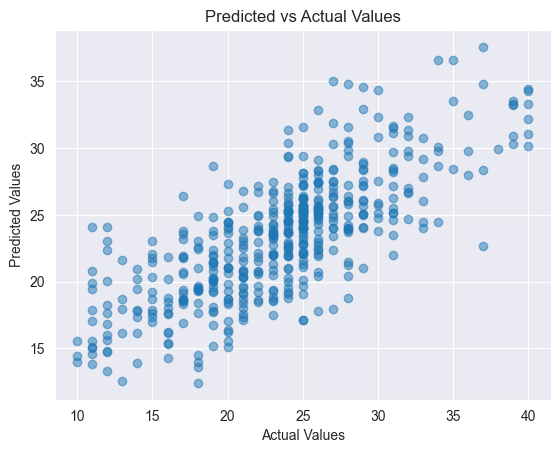

RandomForestRegressor:
  MAE: 3.0515
  MSE: 15.5151
  RMSE: 3.9389
  R²: 0.5765
------------------------------


0.5764830305655881

In [87]:
evaluate(baseline_model, X_test_scaled, y_test)

# SHAP for feature selection

In [88]:
import shap

In [89]:
explainer = shap.Explainer(baseline_model, X_train_scaled, feature_names=X_train.columns)
shap_values = explainer(X_train_scaled, check_additivity=False)

 98%|===================| 1938/1974 [00:50<00:00]        

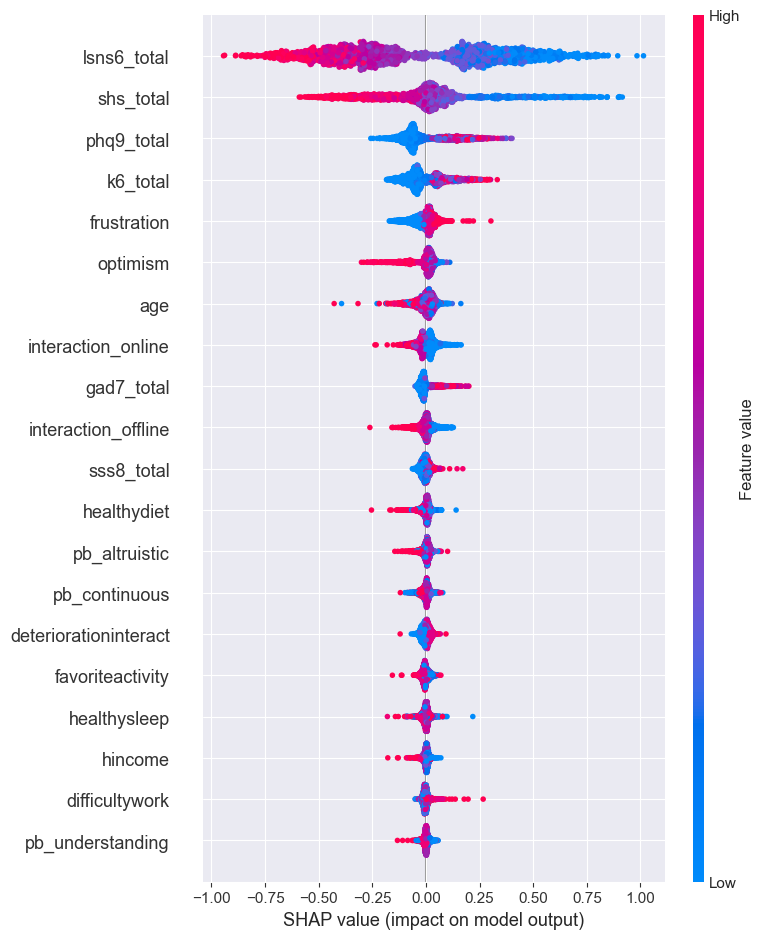

In [90]:
# Create summary plot
shap.summary_plot(shap_values, X_train_scaled)

# (Optional) Show the plot explicitly if needed
plt.show()

# Model Tuning

In [91]:
import pprint
import joblib as job
import time

from sklearn.model_selection import GridSearchCV

pp = pprint.PrettyPrinter(indent=1)

In [92]:
# Define hyperparameter space
n_estimators = [100, 250, 500, 1000]                       # Range of trees
max_features = [1, 2, 3, 4]                                # Feature selection
max_depth = [int(x) for x in np.linspace(10, 100, num=10)]
max_depth.append(None) # Depth
min_samples_split = [2, 5, 10, 15]                     # Control overfitting
min_samples_leaf = [1, 2, 4, 6]                       # Prevent overfitting
bootstrap = [True, False]                              # Sampling strategy
cv = 10                                         # Cross-validation folds

# Create the random grid
random_grid = {'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

print('Hyperparameter search space')
pp.pprint(random_grid)

Hyperparameter search space
{'bootstrap': [True, False],
 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
 'max_features': [1, 2, 3, 4],
 'min_samples_leaf': [1, 2, 4, 6],
 'min_samples_split': [2, 5, 10, 15],
 'n_estimators': [100, 250, 500, 1000]}


In [93]:
# Set model to RandomForestRegressor
model = RandomForestRegressor(random_state=random_state)

In [94]:
start_time = time.time()
grid_tuner = GridSearchCV(estimator=model, param_grid=random_grid, cv=cv, scoring='r2', 
                     verbose=6, return_train_score=True, n_jobs=10)
print('\nCross-validation via', grid_tuner)

# Fit the random search model
print("Fitting the Grid Search model...")
grid_tuner.fit(X_train_scaled, y_train_scaled.ravel())
print("Grid Search CV completed.")

end_time = time.time()
running_time = end_time - start_time
print('\nRandom Forest training time:', running_time, 's')


Cross-validation via GridSearchCV(cv=10, estimator=RandomForestRegressor(random_state=8), n_jobs=10,
             param_grid={'bootstrap': [True, False],
                         'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100,
                                       None],
                         'max_features': [1, 2, 3, 4],
                         'min_samples_leaf': [1, 2, 4, 6],
                         'min_samples_split': [2, 5, 10, 15],
                         'n_estimators': [100, 250, 500, 1000]},
             return_train_score=True, scoring='r2', verbose=6)
Fitting the Grid Search model...
Fitting 10 folds for each of 5632 candidates, totalling 56320 fits
Grid Search CV completed.

Random Forest training time: 6193.941561222076 s


In [95]:
# Save the model
model_name = type(grid_tuner).__name__
file_name = 'phase4_'+ model_name + '_' + time.strftime("%Y%m%d-%H%M%S") + '.mod'
file_save = file_name

print('Saving', model_name, 'model as', file_name, '...')
job.dump(grid_tuner, file_save) 

Saving GridSearchCV model as phase4_GridSearchCV_20250310-003446.mod ...


['phase4_GridSearchCV_20250310-003446.mod']

In [96]:
# Load the model
file_model = 'phase4_GridSearchCV_20250310-003446.mod'
file_load = file_model

saved_model = job.load(file_load) 
tuner = saved_model

print('Best hyperparameters:')
pp.pprint(tuner.best_estimator_.get_params())

Best hyperparameters:
{'bootstrap': False,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 20,
 'max_features': 4,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 1000,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 8,
 'verbose': 0,
 'warm_start': False}


{'n_estimators': [100, 250, 500, 1000], 'max_features': [1, 2, 3, 4], 'max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None], 'min_samples_split': [2, 5, 10, 15], 'min_samples_leaf': [1, 2, 4, 6], 'bootstrap': [True, False]}
n_estimators = 100 : 0.5258755512675963
n_estimators = 250 : 0.5273631662415998
n_estimators = 500 : 0.529465241348635
n_estimators = 1000 : 0.5302302027051502
max_features = 1 : 0.44989734836791373
max_features = 2 : 0.5287024665750508
max_features = 3 : 0.5588382511479572
max_features = 4 : 0.5754960954720596
max_depth = 10 : 0.5187669191196596
max_depth = 20 : 0.5291187899522629
max_depth = 30 : 0.5291832771048375
max_depth = 40 : 0.5291862758675262
max_depth = 50 : 0.5291876448883978
max_depth = 60 : 0.5291876728942526
max_depth = 70 : 0.5291876728942526
max_depth = 80 : 0.5291876728942526
max_depth = 90 : 0.5291876728942526
max_depth = 100 : 0.5291876728942526
max_depth = None : 0.5291876728942526
min_samples_split = 2 : 0.5312599041967586
min_samples_sp

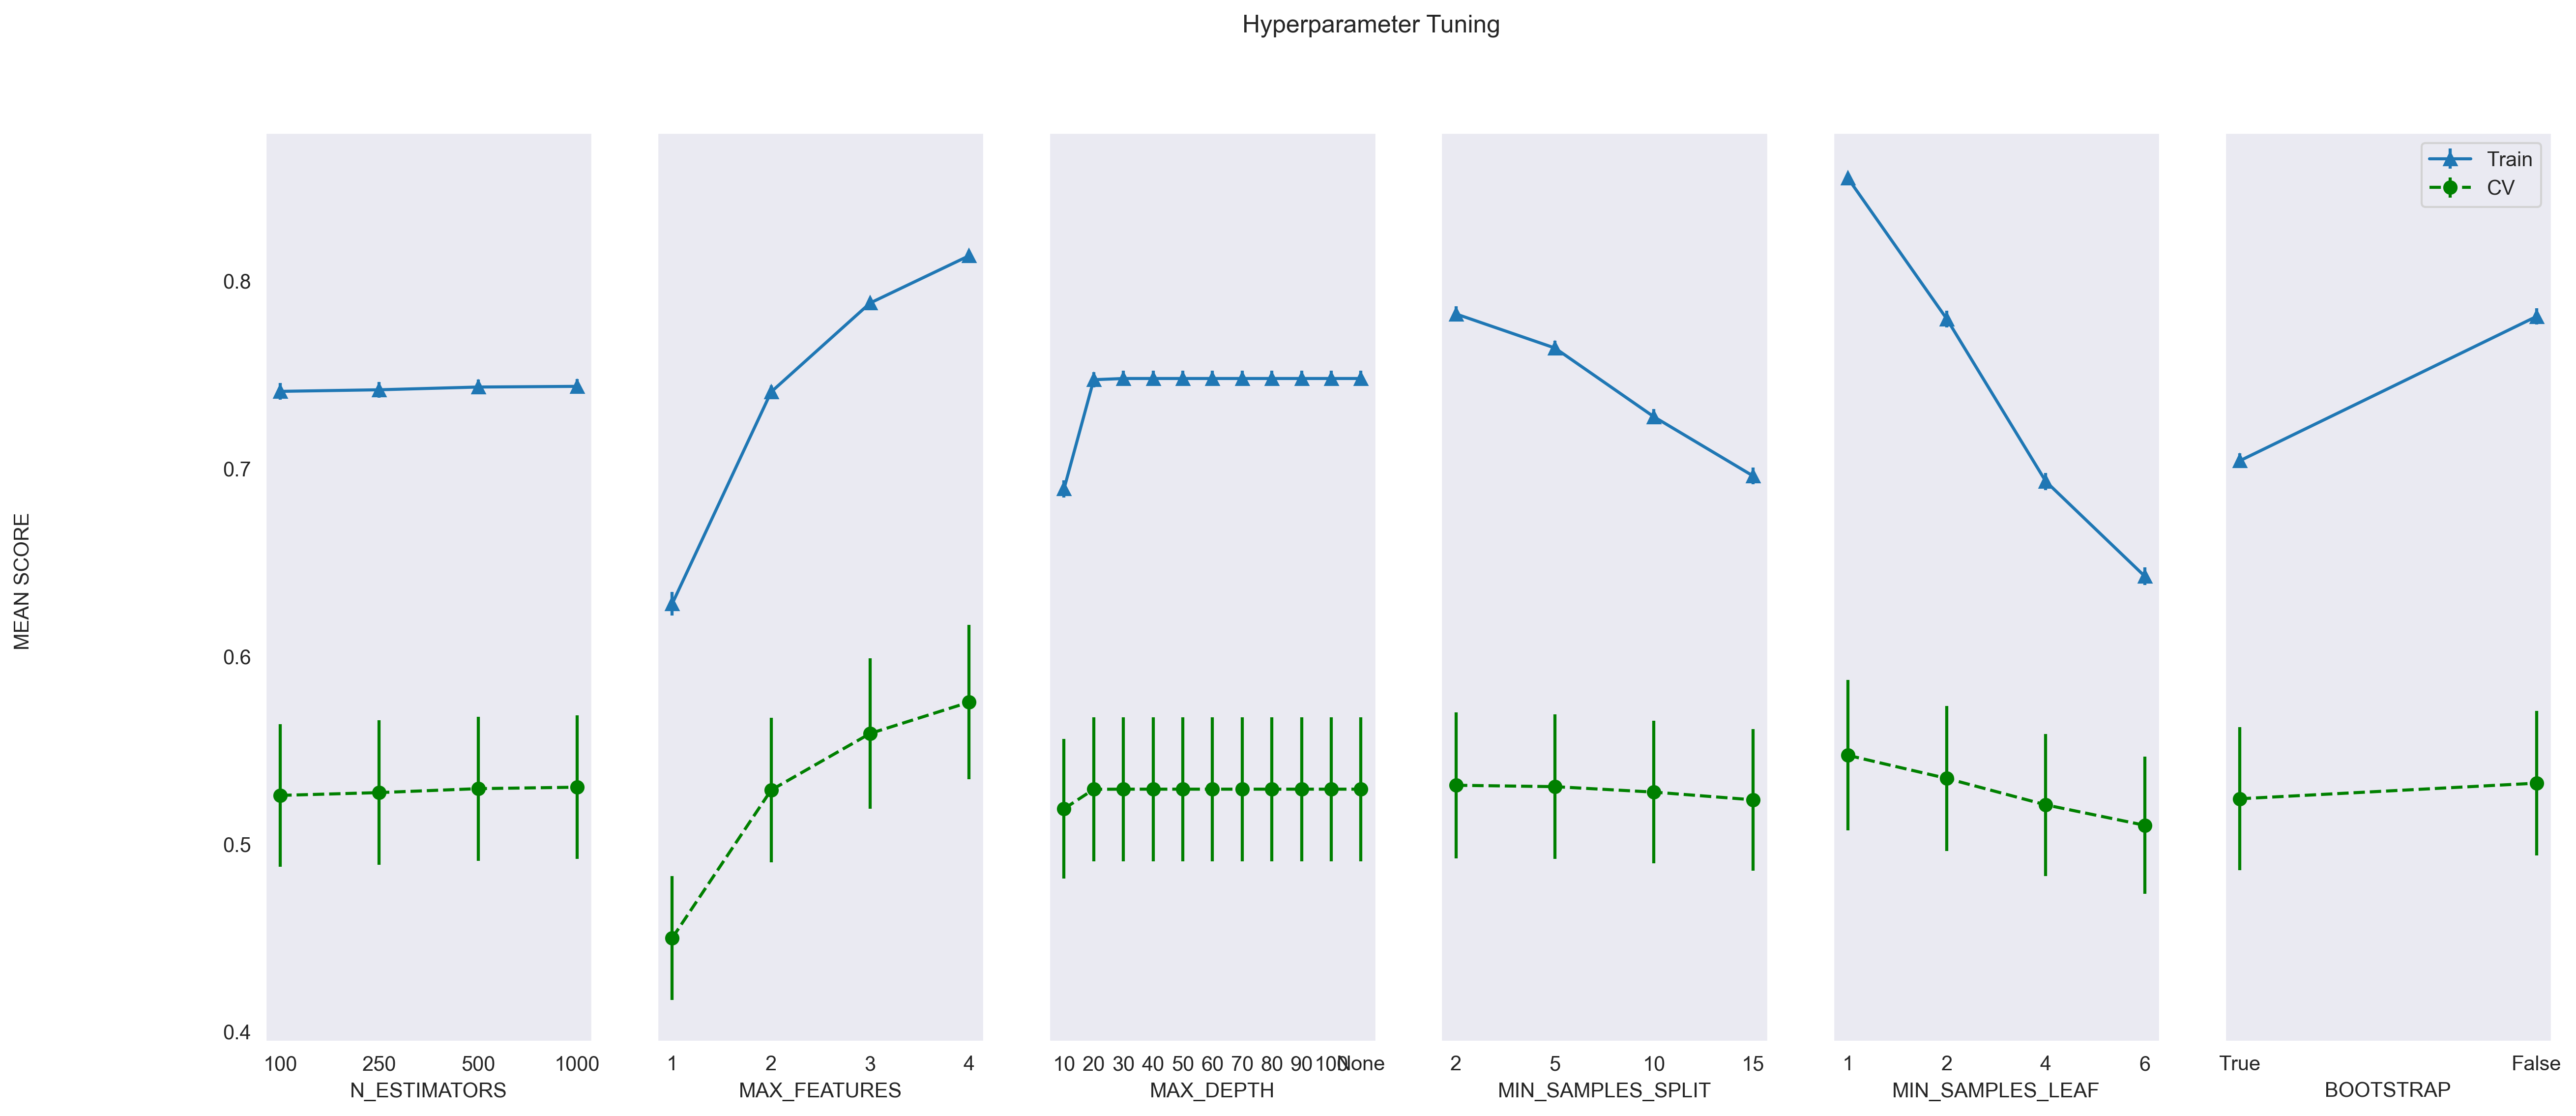

{'mean_fit_time': array([0.16762257, 0.42629104, 0.82087147, ..., 0.5193722 , 1.03274508,
       2.05811591]), 'std_fit_time': array([0.00334891, 0.00439352, 0.00990359, ..., 0.01712311, 0.01875679,
       0.04509851]), 'mean_score_time': array([0.01165888, 0.02752991, 0.04857917, ..., 0.02565296, 0.04860873,
       0.09598143]), 'std_score_time': array([0.00075108, 0.00123065, 0.00434546, ..., 0.00336184, 0.00529688,
       0.0053249 ]), 'param_bootstrap': masked_array(data=[True, True, True, ..., False, False, False],
             mask=[False, False, False, ..., False, False, False],
       fill_value=True), 'param_max_depth': masked_array(data=[10, 10, 10, ..., None, None, None],
             mask=[False, False, False, ..., False, False, False],
       fill_value='?',
            dtype=object), 'param_max_features': masked_array(data=[1, 1, 1, ..., 4, 4, 4],
             mask=[False, False, False, ..., False, False, False],
       fill_value=999999), 'param_min_samples_leaf': masked

In [97]:
## Plot CV results
def plot_cv(tuner):
    results = tuner.cv_results_
    cv_params = tuner.param_grid
    means_test = results['mean_test_score']
    stds_test = results['std_test_score']
    means_train = results['mean_train_score']
    stds_train = results['std_train_score']

    print(cv_params)
    fig, ax = plt.subplots(1, len(cv_params), sharex='none', sharey='all', figsize=(20,8), dpi=300)
    fig.suptitle('Hyperparameter Tuning')
    fig.text(0.04, 0.5, 'MEAN SCORE', va='center', rotation='vertical')

    scores = {}
    for i, (param, param_val) in enumerate(cv_params.items()):
        x, y1, e1, y2, e2 = [], [], [], [], []

        for v in param_val:
            mask_idx = results['param_'+param]==v
            v = str(v)

            m_train = np.mean(means_train[mask_idx])
            s_train = np.sqrt(np.mean(stds_train[mask_idx]**2))
            m_test = np.mean(means_test[mask_idx])    
            s_test = np.sqrt(np.mean(stds_test[mask_idx]**2))

            scores[param+'='+v+'_means_train'] = m_train
            scores[param+'='+v+'_stds_train'] = s_train    
            scores[param+'='+v+'_means_test'] = m_test
            scores[param+'='+v+'_stds_test'] = s_test
            print(param, "=", v, ":", m_test)

            x.append(v)
            y1.append(m_train)
            e1.append(s_train) 
            y2.append(m_test) 
            e2.append(s_test)

        ax[i].errorbar(x, y1, e1, linestyle='-', marker='^', label='Train')
        ax[i].errorbar(x, y2, e2, linestyle='--', marker='o', color='g', label='CV')
        ax[i].set_xlabel(param.upper())

    pp.pprint(scores)

    plt.legend()
    plt.show()

sns.set_style('dark')
plot_cv(saved_model)
print(tuner.cv_results_)

Base model


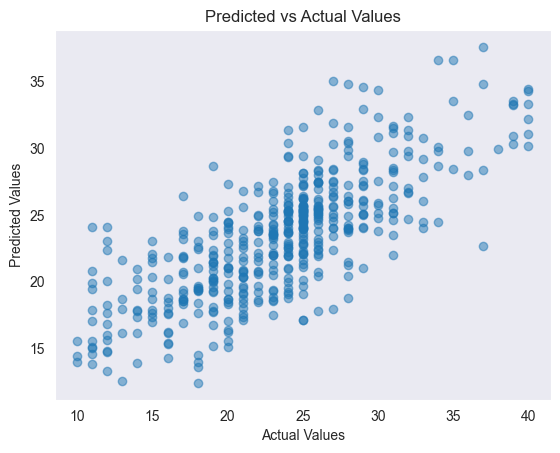

RandomForestRegressor:
  MAE: 3.0515
  MSE: 15.5151
  RMSE: 3.9389
  R²: 0.5765
------------------------------

Tuned model


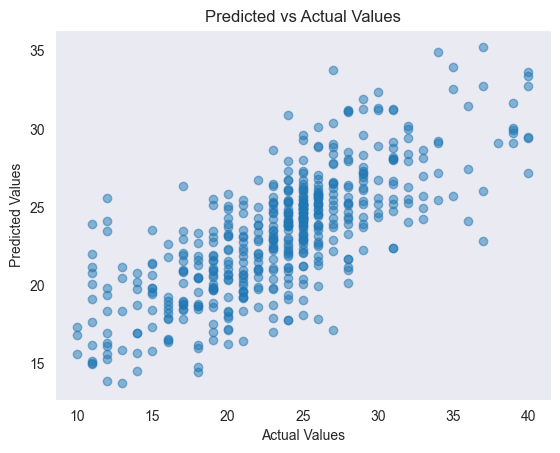

RandomForestRegressor:
  MAE: 3.0426
  MSE: 16.3997
  RMSE: 4.0497
  R²: 0.5523
------------------------------

Saved model


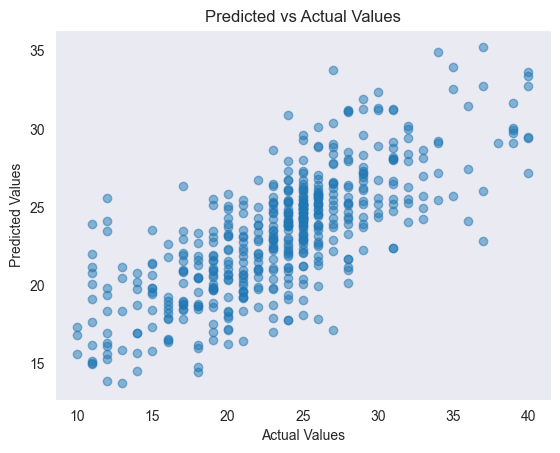

RandomForestRegressor:
  MAE: 3.0426
  MSE: 16.3997
  RMSE: 4.0497
  R²: 0.5523
------------------------------

Improvement: -0.0241


In [98]:
## Evaluate model
print('Base model')
base_model = RandomForestRegressor(random_state=random_state)
base_model.fit(X_train_scaled, y_train_scaled.ravel())
base_accuracy = evaluate(base_model, X_test_scaled, y_test)

print('\nTuned model')
tuned_model = tuner.best_estimator_
tuned_accuracy = evaluate(tuned_model, X_test_scaled, y_test)

print('\nSaved model')
saved_accuracy = evaluate(saved_model.best_estimator_, X_test_scaled, y_test)

print('\nImprovement: {:0.4f}'.format(tuned_accuracy - base_accuracy))